In [1]:

import warnings, json
from pathlib import Path
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, f1_score
)
from sklearn.linear_model import LogisticRegression
import joblib

In [2]:
warnings.filterwarnings("ignore")

In [3]:
FILE_PATH = "processing_data_1.xlsx"   # đổi nếu cần
ARTIFACT_DIR = Path("supervised_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
CANDIDATE_TARGETS = ["is_duplicate", "rating_bucket_ord", "sold_bucket_ord"]

In [5]:
# Cột không dùng làm feature (rò rỉ/ID/đường dẫn/diễn giải)
DROP_COLS = [
    "id", "image_path_x", "thumbnail_url", "image_path_y",
    "dup_representative",
    *[f"dup_path_{i}" for i in range(1, 10)],
    *[f"dup_id_{i}" for i in range(1, 10)],
    "name", "name_norm", "name_key",
    "model_hint", "model_norm", "model_key",
    "brand", "brand_norm", "brand_key",
]
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5  # dùng cho báo cáo CV nhanh

In [6]:
def pick_target(df: pd.DataFrame) -> str:
    for c in CANDIDATE_TARGETS:
        if c in df.columns:
            return c
    # fallback: tìm cột kiểu cờ (is_* hoặc *_flag) và có <=3 giá trị khác nhau
    for c in df.columns:
        if (c.startswith("is_") or c.endswith("_flag")) and df[c].dropna().nunique() <= 3:
            return c
    raise ValueError("Không tìm thấy cột nhãn phù hợp. Hãy thêm is_duplicate hoặc rating_bucket_ord/sold_bucket_ord.")

def cast_numeric_if_possible(X: pd.DataFrame) -> pd.DataFrame:
    """Thử ép các cột object sang số nếu phần lớn giá trị chuyển được."""
    for c in list(X.columns):
        if not pd.api.types.is_numeric_dtype(X[c]):
            casted = pd.to_numeric(X[c], errors="coerce")
            if np.isfinite(casted).mean() > 0.6:  # >60% parse được số
                X[c] = casted
    return X

def build_preprocessor(X: pd.DataFrame) -> Tuple[ColumnTransformer, List[str], List[str]]:
    num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    cat_cols = [c for c in X.columns if c not in num_cols]
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    pre = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ],
        remainder="drop"
    )
    return pre, num_cols, cat_cols

def threshold_search(y_true, y_proba, metric="f1", min_recall=None):
    """Tìm ngưỡng tốt nhất theo F1 (hoặc AP), có thể ràng buộc min_recall."""
    best_t, best_score = 0.5, -1
    thresholds = np.linspace(0.01, 0.99, 99)
    for t in thresholds:
        y_hat = (y_proba >= t).astype(int)
        if min_recall is not None:
            from sklearn.metrics import recall_score
            if recall_score(y_true, y_hat) < min_recall:
                continue
        score = f1_score(y_true, y_hat) if metric == "f1" else average_precision_score(y_true, y_proba)
        if score > best_score:
            best_t, best_score = t, score
    return best_t, best_score

In [7]:
df = pd.read_excel(FILE_PATH)
target = pick_target(df)

dfw = df.copy()
y = dfw[target]
X = dfw.drop(columns=[target] + [c for c in DROP_COLS if c in dfw.columns], errors="ignore")

# loại cột toàn NA hoặc constant
drop_na_all = [c for c in X.columns if X[c].isna().all()]
drop_const = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
X = X.drop(columns=drop_na_all + drop_const, errors="ignore")

# ép kiểu số nếu hợp lý
X = cast_numeric_if_possible(X)

# split
stratify = y if y.nunique() <= 20 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=stratify
)

=== CV Scores ===
  accuracy: 0.9056 ± 0.0207
        f1: 0.9062 ± 0.0212
   roc_auc: 0.9290 ± 0.0285
    pr_auc: 0.9015 ± 0.0334

=== Hold-out Classification Report ===
              precision    recall  f1-score   support

           0     0.9857    0.8846    0.9324        78
           1     0.7000    0.9545    0.8077        22

    accuracy                         0.9000       100
   macro avg     0.8429    0.9196    0.8701       100
weighted avg     0.9229    0.9000    0.9050       100

Confusion matrix:
 [[69  9]
 [ 1 21]]


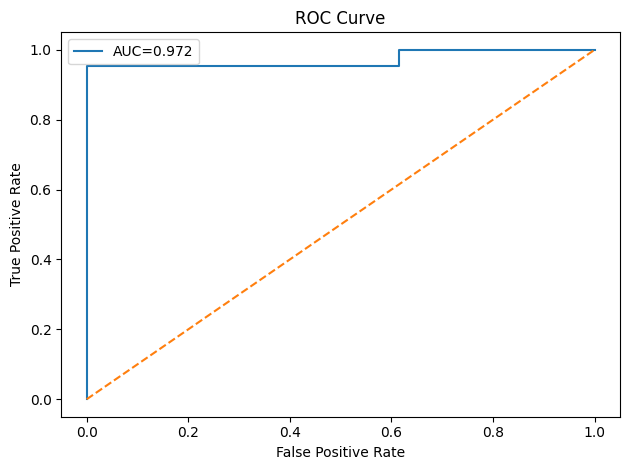

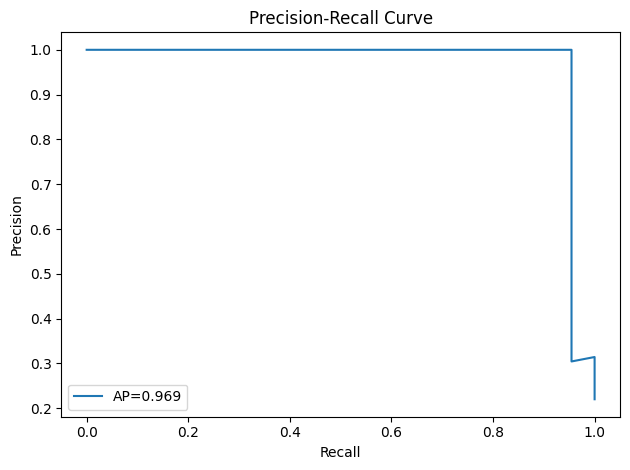

[INFO] Ngưỡng tối ưu theo F1: 0.760 (score=0.9767)

=== Report @Threshold* ===
              precision    recall  f1-score   support

           0     0.9873    1.0000    0.9936        78
           1     1.0000    0.9545    0.9767        22

    accuracy                         0.9900       100
   macro avg     0.9937    0.9773    0.9852       100
weighted avg     0.9901    0.9900    0.9899       100

Confusion matrix (opt):
 [[78  0]
 [ 1 21]]


In [8]:
# ================ PREPROCESS & MODEL ================
preprocess, num_cols, cat_cols = build_preprocessor(X)

model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

# CV nhanh (nếu là phân loại)
if y.nunique() <= 20:
    scoring = {
        "accuracy": "accuracy",
        "f1": "f1_weighted",
        "roc_auc": "roc_auc_ovr" if y.nunique() > 2 else "roc_auc",
        "pr_auc": "average_precision",
    }
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print("=== CV Scores ===")
    for k, v in scores.items():
        if k.startswith("test_"):
            arr = v
            print(f"{k[5:]:>10s}: {arr.mean():.4f} ± {arr.std():.4f}")

# fit & evaluate
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n=== Hold-out Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# curves & threshold (binary)
best_threshold = 0.5
if y.nunique() == 2:
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_val = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc_val:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve"); plt.legend(); plt.tight_layout()
    plt.show()

    # PR
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.figure()
    plt.plot(recall, precision, label=f"AP={ap:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision-Recall Curve"); plt.legend(); plt.tight_layout()
    plt.show()

    # Tối ưu ngưỡng theo F1 (có thể đổi min_recall=0.9 nếu muốn ưu tiên recall)
    best_threshold, best_score = threshold_search(y_test, y_proba, metric="f1", min_recall=None)
    print(f"[INFO] Ngưỡng tối ưu theo F1: {best_threshold:.3f} (score={best_score:.4f})")
    y_pred_opt = (y_proba >= best_threshold).astype(int)
    print("\n=== Report @Threshold* ===")
    print(classification_report(y_test, y_pred_opt, digits=4))
    print("Confusion matrix (opt):\n", confusion_matrix(y_test, y_pred_opt))

In [9]:
# ================ LƯU ARTIFACTS ================
# 1) Lưu mô hình
model_path = ARTIFACT_DIR / "best_model_logreg.joblib"
joblib.dump(model, model_path)

# 2) Metadata cột nguồn (trước encode)
meta = pd.DataFrame({"feature": X.columns, "dtype": [str(X[c].dtype) for c in X.columns]})
meta_path = ARTIFACT_DIR / "features_metadata.csv"
meta.to_csv(meta_path, index=False)

# 3) README
readme_path = ARTIFACT_DIR / "README.txt"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(
        f"""Supervised Learning Artifacts
File: {FILE_PATH}
Target: {target}
Rows: {len(df)}
Features used: {len(X.columns)} (dropped: {len(DROP_COLS)} + all-NA/constant)
Numeric: {len(num_cols)}, Categorical: {len(cat_cols)}
Model: LogisticRegression (class_weight='balanced')
Best threshold (binary only): {best_threshold if y.nunique()==2 else 'N/A'}
"""
    )

# 4) Xuất dự đoán cho toàn bộ data (giữ nguyên index gốc)
out = dfw.copy()
try:
    proba_all = model.predict_proba(X)[:, 1] if y.nunique()==2 else None
except Exception:
    proba_all = None

pred_all = model.predict(X)
out[f"pred_{target}"] = pred_all
if proba_all is not None:
    out[f"proba_{target}"] = proba_all
    out[f"pred_{target}_thr_{str(best_threshold).replace('.','_')}"] = (proba_all >= best_threshold).astype(int)

pred_path = ARTIFACT_DIR / "labeled_predictions.xlsx"
out.to_excel(pred_path, index=False)

# 5) (Tuỳ chọn) Hệ số/độ quan trọng đặc trưng cho Logistic Regression
#    Lưu ý: vì có OneHot, độ quan trọng nằm ở không gian sau onehot. Lấy top theo |coef|.
try:
    # Lấy tên cột sau preprocess
    ohe = model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
    num_names = num_cols
    cat_names = list(ohe.get_feature_names_out(cat_cols))
    all_names = np.array(num_names + cat_names)

    clf = model.named_steps["clf"]
    coefs = clf.coef_[0] if y.nunique()==2 else np.mean(np.abs(clf.coef_), axis=0)
    importance = pd.DataFrame({"feature_after_encode": all_names, "abs_coef": np.abs(coefs)})
    top_imp = importance.sort_values("abs_coef", ascending=False).head(50)
    top_imp_path = ARTIFACT_DIR / "top_features_logreg.csv"
    top_imp.to_csv(top_imp_path, index=False)
except Exception as e:
    print(f"[WARN] Không trích xuất được feature importance sau one-hot: {e}")

print("\n=== DONE ===")
print("Model:", model_path.as_posix())
print("Metadata:", meta_path.as_posix())
print("Predictions:", pred_path.as_posix())


=== DONE ===
Model: supervised_artifacts/best_model_logreg.joblib
Metadata: supervised_artifacts/features_metadata.csv
Predictions: supervised_artifacts/labeled_predictions.xlsx
